In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from numpy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D
import scipy.linalg as la
import helpers as stoOpinf
import PSD_utils
import capillary_wave_analysis as cwa
from IPython.display import display, Math
from scipy.io import loadmat
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams.update({
    "text.usetex": False,  # keep False (faster, no LaTeX dependency)
    "mathtext.fontset": "cm",  # THIS enables Computer Modern / Latin Modern math
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "Computer Modern Roman", "DejaVu Serif"],

    "xtick.labelsize": 15,  # x-axis tick labels
    "ytick.labelsize": 15,  # y-axis tick labels
})

In [3]:
%load_ext autoreload
%autoreload 2

In [242]:
power_labels = {
    "0p04": list("abcdefghijklmnop"),
    "0p07": list("abcdefghijklnop"), # or no "m"
    "0p08": list("abcefghijklnop"), # no d and m
    "0p10": list("bcdefhijklmnopq"),  # or "bcdefhijklmnopq"
    "0p15": list("abcdefghijklmnop"),
    "0p18": list("abcdefghijkmnop"), # or "acegijkmop"
    # "0p20": list("abcdefghij"),
    "0p20": list("abcdefghijklmnop"),
    "0p25": list("abcdefghijklmnop"),
    "0p30": list("abcdefghijklmnop"),
    "0p35": list("abcdefhijklmnop"),
}

power = "0p10"

Q, t, x, nx = stoOpinf.load_Q_dataset(power, power_labels[power])

In [243]:
Q_split, Qstate_all, X_mean, tt = stoOpinf.preprocess_Q(Q, t, labels = power_labels[power])

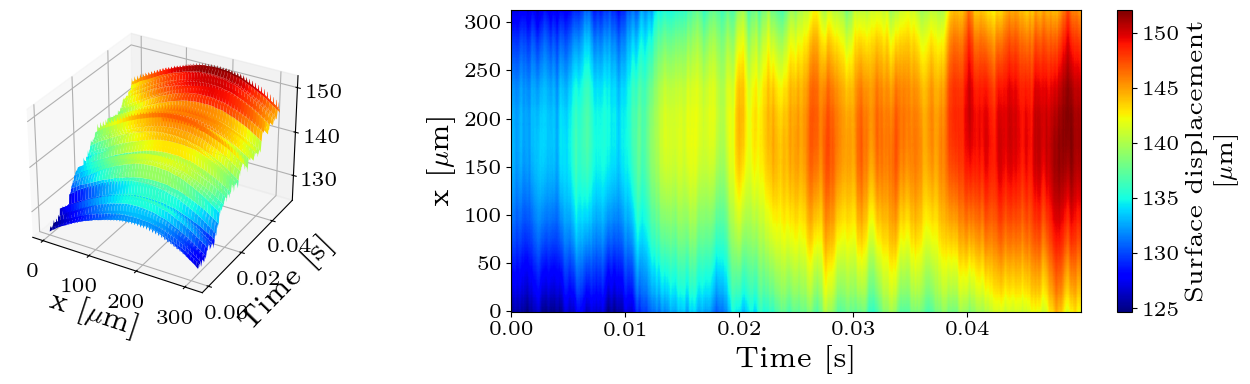

In [244]:
T, X = np.meshgrid(tt, x)
Z = Qstate_all.mean(axis=1)

fig = plt.figure(figsize=(15, 4))

# 3D surface plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf = ax1.plot_surface(
    X, T, Z, cmap='jet', edgecolor='none'
)
ax1.set_xlabel('x [$\\mu$m]', fontsize=20)
ax1.set_ylabel('Time [s]', fontsize=20)

# 2D colormap
ax2 = fig.add_subplot(1, 2, 2)

pcm = ax2.pcolormesh(
    T, X, Z, shading='auto', cmap='jet'
)
ax2.set_xlabel('Time [s]', fontsize=20)
ax2.set_ylabel('x [$\\mu$m]', fontsize=20)

cbar = fig.colorbar(pcm, ax=ax2)
cbar.set_label('Surface displacement\n[$\\mu$m]', fontsize=18)

plt.tight_layout()
plt.show()

In [245]:
print("Computing POD basis...")
Qmat = Qstate_all.reshape(nx, -1)
V, S, _ = svd(Qmat, full_matrices=False)
print("Basis computed.")

Computing POD basis...
Basis computed.


In [246]:
_, L, s = Qstate_all.shape  # L, s
h_test = t[1] - t[0]  # time step

EFOM = np.mean(Qstate_all, 1)

tt_test = tt

f0 = 7
f_input = f0 * 1e6
u_amp = 1
u_train = u_amp * np.cos(2 * np.pi * f_input * tt_test)

In [390]:
# Hyperparameters
A_reg      = np.logspace(-1, 5, 10)
B_reg_arr  = np.logspace(0, 8, 10)
N_reg      = np.logspace(8, 10, 10)

A_reg_test = 0
B_reg      = 0
H_reg_opt  = 1e1
sigma      = 1
r_opt      = 40

isbilinear = True
isBu       = True
seed_test  = 42

ROM_form = 'A' + ('B' if isBu else '') + ('N' if isbilinear else '')

# ROM basis and projections
Vr_temp      = V[:, :r_opt]                          # nx x r
Q_train_temp = Vr_temp.T @ Qstate_all.reshape(Vr_temp.shape[0], L*s)  
Q_train_temp = Q_train_temp.reshape(r_opt, L, s)     # r x L x s

E_train = Q_train_temp.mean(axis=1)                 # r x s
C_train = np.stack([np.cov(Q_train_temp[:,:,k])     # r x r x s
                    for k in range(s)], axis=2)

# Loop ranges
if isBu:
    B_loop = np.arange(1)
    B_reg = np.array([B_reg])
    # B_reg = B_reg_arr
else:
    B_loop = np.array([0])
    B_reg  = np.array([0.0])

# Lambda factory
def get_lambda(ii, jj):
    if isbilinear and isBu:
        return np.array([A_reg_test, B_reg[jj], N_reg[ii]])
    elif isbilinear and not isBu:
        return np.array([A_reg_test, N_reg[ii]])
    elif not isbilinear and isBu:
        return np.array([A_reg[ii],  B_reg[jj], 0.0])
    else:
        return np.array([A_reg[ii]])

# Storage
n_outer = len(N_reg)
n_inner = len(B_loop)

Eopinfs  = [[None]*n_inner for _ in range(n_outer)]
Copinfs  = [[None]*n_inner for _ in range(n_outer)]
EROM     = [[None]*n_inner for _ in range(n_outer)]
CROM     = [[None]*n_inner for _ in range(n_outer)]
ROMs_all = [[None]*n_inner for _ in range(n_outer)]

E_error  = np.zeros((n_outer, n_inner))
C_error  = np.zeros((n_outer, n_inner))

In [391]:
results = stoOpinf.run_grid_search(
    E_train, C_train, Q_train_temp, u_train, h_test,
    N_reg, B_reg, A_reg, Vr_temp,
    isbilinear, isBu, H_reg_opt, sigma,
    n_outer, B_loop, get_lambda,
    L, s, seed_test
)

Eopinfs, Copinfs = results['Eopinfs'], results['Copinfs']
EROM, CROM       = results['EROM'],    results['CROM']
E_error, C_error = results['E_error'], results['C_error']
ROMs_all         = results['ROMs_all']
Xr_opinfs        = results["Xr_opinfs"]


1th N_reg = 1.00e+08

  lambda = [0.e+00 0.e+00 1.e+08]

     k |    C_train |     Copinf |    C err |    E_train |     Eopinf |    E err
--------------------------------------------------------------------------------
     1 |   4.05e+06 |   4.05e+06 |    0.05% |   1.85e+03 |   1.85e+03 |    0.01%
  1441 |   4.09e+06 |   5.10e+06 |   26.52% |   1.93e+03 |   1.97e+03 |    2.64%
  2881 |   4.15e+06 |   4.87e+06 |   21.02% |   2.02e+03 |   2.11e+03 |    4.41%
  4321 |   4.42e+06 |   5.89e+06 |   36.52% |   2.03e+03 |   2.23e+03 |   10.13%
  5760 |   4.35e+06 |   5.80e+06 |   37.27% |   2.09e+03 |   2.33e+03 |   11.29%
--------------------------------------------------------------------------------
   Avg |            |            |   27.58% |            |            |    8.16%

  Elapsed: 5.48s

2th N_reg = 1.67e+08

  lambda = [0.00000000e+00 0.00000000e+00 1.66810054e+08]

     k |    C_train |     Copinf |    C err |    E_train |     Eopinf |    E err
--------------------------------


Best E_error: N_reg=2.15e+09 | E_err=0.082
Best C_error: N_reg=1.00e+10 | C_err=0.276


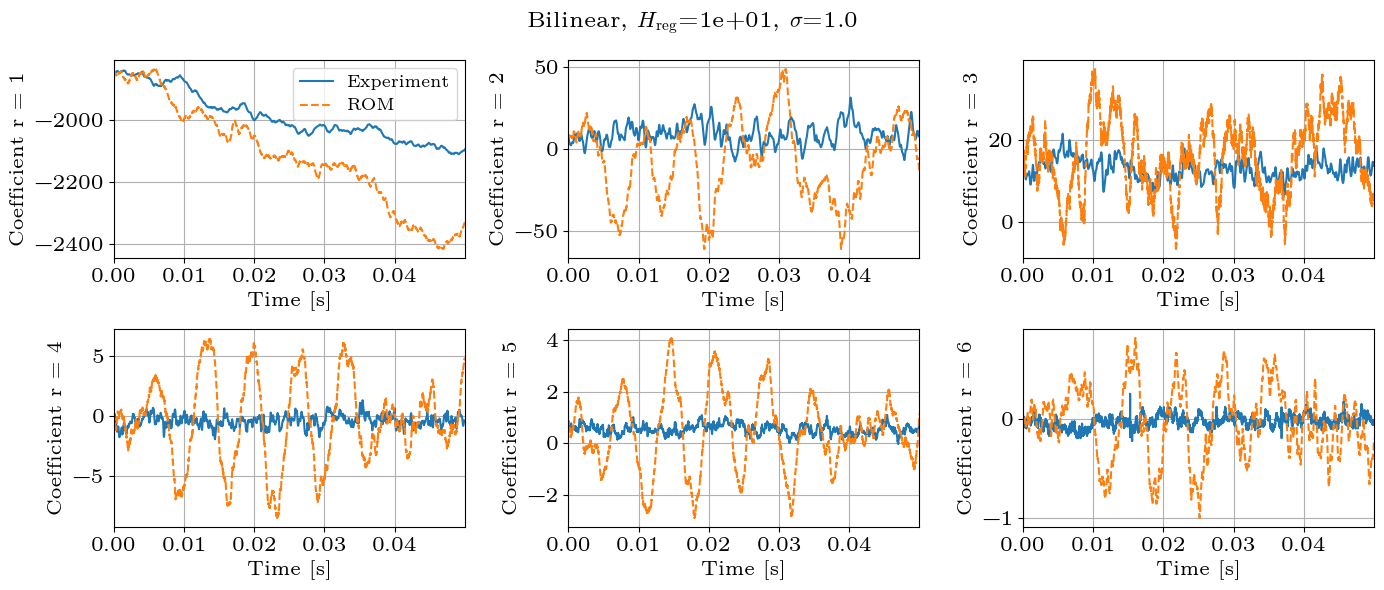

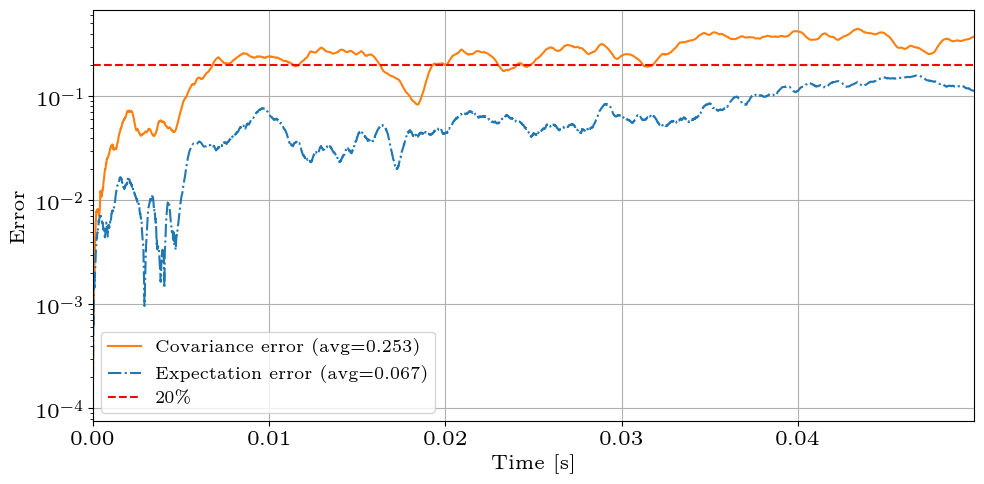

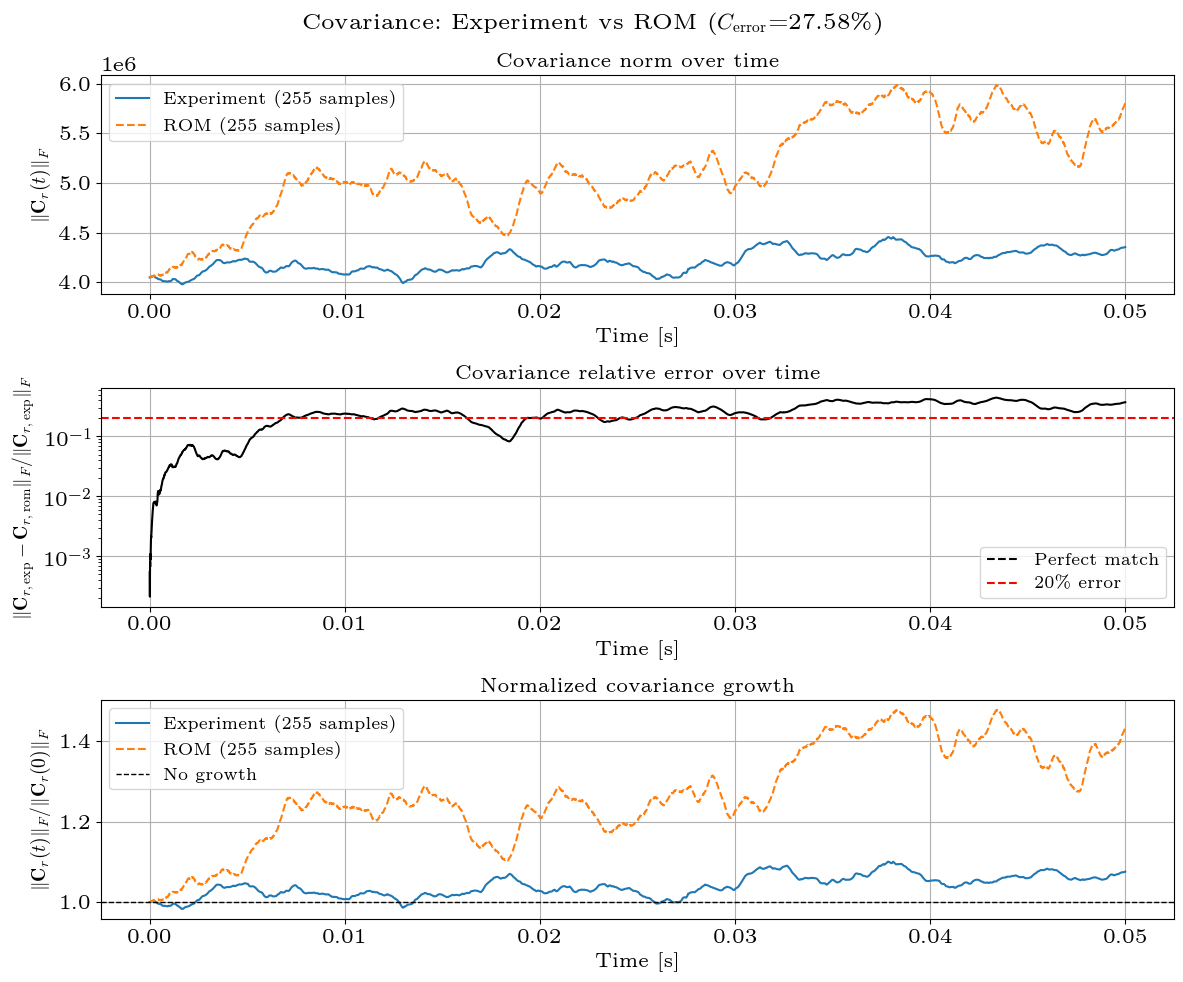

In [392]:
results = stoOpinf.analyze_rom_results(
    E_error, C_error,
    Eopinfs, Copinfs,
    E_train, C_train,
    tt, N_reg,
    H_reg_opt, sigma, L,
)
Eopinf_opt = results["Eopinf_opt"]
Copinf_opt = results["Copinf_opt"]
i_Emin, j_Emin = results["i_Emin"], results["j_Emin"]
i_Cmin, j_Cmin = results["i_Cmin"], results["j_Cmin"]

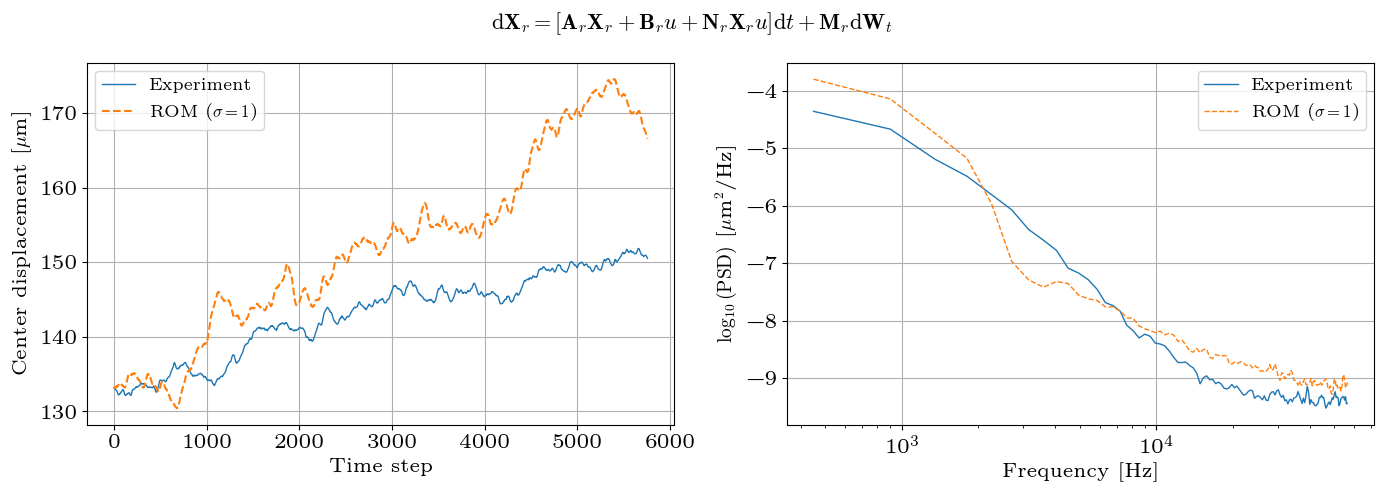

In [394]:
EROM_opt = EROM[i_Emin][j_Emin]

i_center = 100

k_FOM, psd_FOM, f_FOM, slope_FOM, *_ = PSD_utils.compute_PSD(EFOM[i_center, :], 115_250, 5, 100)
k_ROM, psd_ROM, f_ROM, slope_ROM, *_ = PSD_utils.compute_PSD(EROM_opt[i_center, :], 115_250, 5, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='w')

ax1.plot(EFOM[i_center, :], lw=1, color='C0', label="Experiment")
ax1.plot(EROM_opt[i_center, :], lw=1.5, ls="--", color='C1',
        label=f"ROM ($\\sigma={sigma}$)")

ax1.set_xlabel("Time step", fontsize=14)
ax1.set_ylabel(r"Center displacement [$\mu$m]", fontsize=14)
ax1.legend()
ax1.grid(True)

ax2.plot(f_FOM, psd_FOM, lw=1, color='C0', label='Experiment')
ax2.plot(f_ROM, psd_ROM, lw=1, ls="--", color='C1',
        label=f'ROM ($\\sigma={sigma}$)')

ax2.set_xscale('log')
ax2.set_xlabel("Frequency [Hz]", fontsize=14)
ax2.set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/Hz]", fontsize=14)
ax2.legend()
ax2.grid(True)

# Title (model form)
if ROM_form == 'ABN':
        title = (r"$\mathrm{d}\mathbf{X}_r = [\mathbf{A}_r\mathbf{X}_r + "
                r"\mathbf{B}_r u + \mathbf{N}_r\mathbf{X}_r u]\mathrm{d}t "
                r"+ \mathbf{M}_r \mathrm{d}\mathbf{W}_t$")
elif ROM_form == 'AB':
        title = (r"$\mathrm{d}\mathbf{X}_r = [\mathbf{A}_r\mathbf{X}_r + "
                r"\mathbf{B}_r u]\mathrm{d}t + \mathbf{M}_r \mathrm{d}\mathbf{W}_t$")
elif ROM_form == 'AN':
        title = (r"$\mathrm{d}\mathbf{X}_r = [\mathbf{A}_r\mathbf{X}_r + "
                r"\mathbf{N}_r\mathbf{X}_r u]\mathrm{d}t + \mathbf{M}_r \mathrm{d}\mathbf{W}_t$")
else:
        title = "ROM model"

fig.suptitle(title, fontsize=16)

plt.tight_layout()
plt.show()

In [303]:
# Ahatr = ROMs_all[i_Emin][j_Emin]['Ahat']
# Nhatr = ROMs_all[i_Emin][j_Emin]['Nhat']
# Bhatr = ROMs_all[i_Emin][j_Emin]['Bhat']
# display(Math(r"\|A_r\|_F = %.2e" % la.norm(Ahatr, 'fro')))
# display(Math(r"\|B_r\|_F = %.2e" % la.norm(Bhatr, 'fro')))
# display(Math(r"\|N_r\|_F = %.2e" % la.norm(Nhatr, 'fro')))

In [274]:
# fig, ax = plt.subplots(1, 1, figsize=(14, 5), facecolor='w')

# for iL in range(L):
#     ax.plot(Qstate_all[i_center, iL, :], lw=1, color='C0')
#     ax.plot(EROM_all_traj[i_center, iL, :], lw=1.5, ls="--", color='C1')

#     ax.set_xlabel("Time step", fontsize=14)
#     ax.set_ylabel(r"Center displacement [$\mu$m]", fontsize=14)
#     # ax.legend()
#     ax.grid(True)

In [268]:
psd_true_all = []
for iL in range(L):
    k_FOM, psd_seg, f_FOM, *_ = PSD_utils.compute_PSD(Qstate_all[i_center, iL, :], 115_250, 5, 100)
    psd_true_all.append(psd_seg)

In [269]:
# Compute the PSD bias through averaging time series
for iL in range(L):
    if iL == 0:
        psd_avg = psd_true_all[iL]
    else:
        psd_avg = (psd_avg + psd_true_all[iL])/2

# psd bias thru averaging    
psd_diff_exp = np.abs(psd_FOM - psd_avg)

In [386]:
# Reconstruct EROM trajectories using the optimal Eopinf
Xr_opinfs_opt = Xr_opinfs[i_Emin][j_Emin]
EROM_all_traj = np.einsum('ir, rls->ils', Vr_temp, Xr_opinfs_opt)

# PSDs of all ROM trajectories
psd_ROM_all = []
for iL in range(L):
    k_FOM, psd_seg, f_FOM, *_ = PSD_utils.compute_PSD(EROM_all_traj[i_center, iL, :], 115_250, 5, 100)
    psd_ROM_all.append(psd_seg)

In [387]:
# Compute the PSD bias through averaging time series
for iL in range(L):
    if iL == 0:
        psd_avg = psd_ROM_all[iL]
    else:
        psd_avg = (psd_avg + psd_ROM_all[iL])/2

# psd bias thru averaging    
psd_diff_rom = np.abs(psd_ROM - psd_avg)

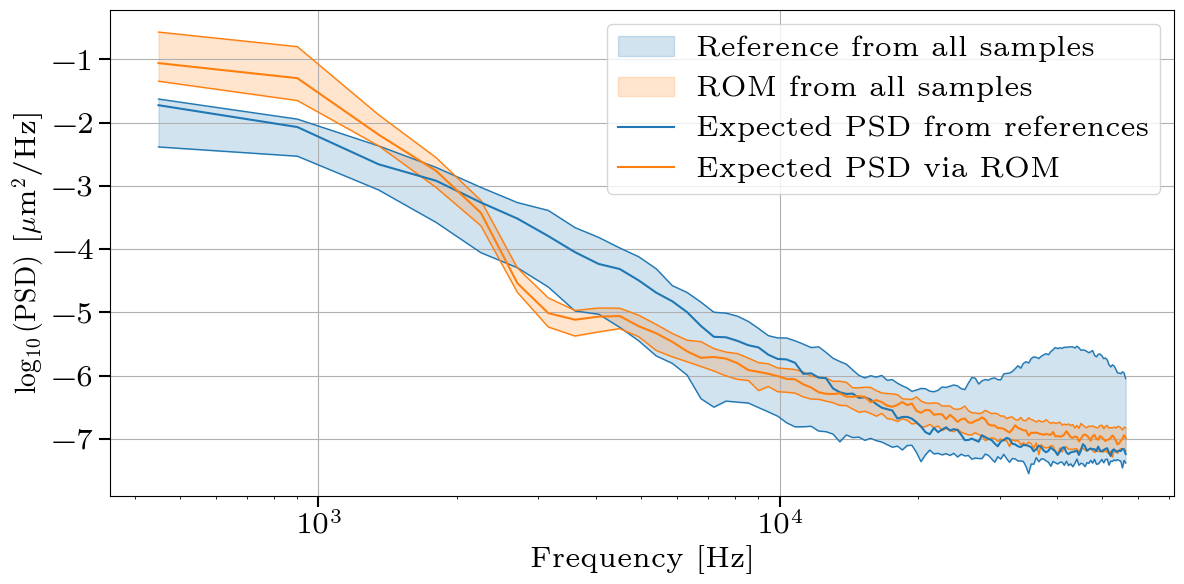

In [388]:
fig, ax = plt.subplots(figsize=(12, 6))

# Envelope of reference PSDs
psd_min_exp = np.min(psd_true_all, axis=0)
psd_max_exp = np.max(psd_true_all, axis=0)
psd_min_rom = np.min(psd_ROM_all, axis=0)
psd_max_rom = np.max(psd_ROM_all, axis=0)

# Plot interval band
ax.fill_between(f_FOM, psd_min_exp, psd_max_exp, color='C0', alpha=0.2, label='Reference from all samples')
ax.plot(f_FOM, psd_min_exp, color='C0', lw=1.0, alpha=1.0)
ax.plot(f_FOM, psd_max_exp, color='C0', lw=1.0, alpha=1.0)

ax.fill_between(f_FOM, psd_min_rom, psd_max_rom, color='C1', alpha=0.2, label='ROM from all samples')
ax.plot(f_FOM, psd_min_rom, color='C1', lw=1.0, alpha=1.0)
ax.plot(f_FOM, psd_max_rom, color='C1', lw=1.0, alpha=1.0)

ax.plot(f_ROM, psd_FOM + psd_diff_exp, lw=1.5, alpha=1, ls='-', color='C0', label='Expected PSD from references')

# ROM PSD
ax.plot(f_ROM, psd_ROM + psd_diff_rom, lw=1.5, alpha=1, ls='-', color='C1', label='Expected PSD via ROM')

ax.set_xscale('log')
ax.set_xlabel("Frequency [Hz]", fontsize=20)
ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/Hz]", fontsize=20)     
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5) 

ax.grid(True)
ax.legend(fontsize=20)
plt.tight_layout()
plt.show()

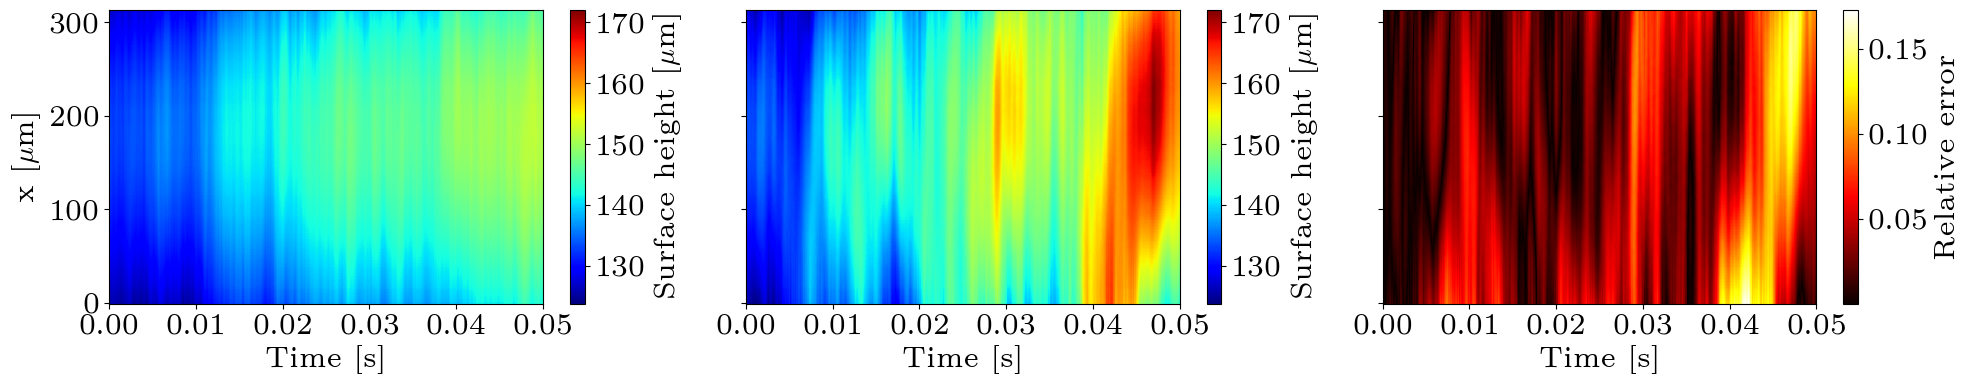

In [389]:
T, X = np.meshgrid(tt, x)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4), sharey=True)

xticks = np.arange(0, 0.06, 0.01)
vmin = min(Qstate_all.mean(axis=1).min(), EROM_opt.min())
vmax = max(Qstate_all.mean(axis=1).max(), EROM_opt.max())

pcm1 = ax1.pcolormesh(T, X, Qstate_all.mean(axis=1), shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
ax1.set_xlabel('Time [s]', fontsize=20)
ax1.set_ylabel('x [$\\mu$m]', fontsize=20)
ax1.set_xticks(xticks)
ax1.tick_params(axis='both', labelsize=20)
cbar1 = fig.colorbar(pcm1, ax=ax1)  
cbar1.ax.tick_params(labelsize=20)
cbar1.set_label('Surface height [$\\mu$m]', fontsize=20)

pcm2 = ax2.pcolormesh(T, X, EROM_opt, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
ax2.set_xlabel('Time [s]', fontsize=20)
ax2.set_xticks(xticks)
ax2.tick_params(axis='both', labelsize=20)
cbar2 = fig.colorbar(pcm2, ax=ax2)
cbar2.ax.tick_params(labelsize=20)
cbar2.set_label('Surface height [$\\mu$m]', fontsize=20)

pcm3 = ax3.pcolormesh(T, X, abs(EFOM - EROM_opt) / abs(EFOM), shading='auto', cmap='hot')
ax3.set_xlabel('Time [s]', fontsize=20)
ax3.set_xticks(xticks)
ax3.tick_params(axis='both', labelsize=20)
cbar3 = fig.colorbar(pcm3, ax=ax3)
cbar3.ax.tick_params(labelsize=20)
cbar3.set_label('Relative error', fontsize=20)

plt.tight_layout()
plt.show()

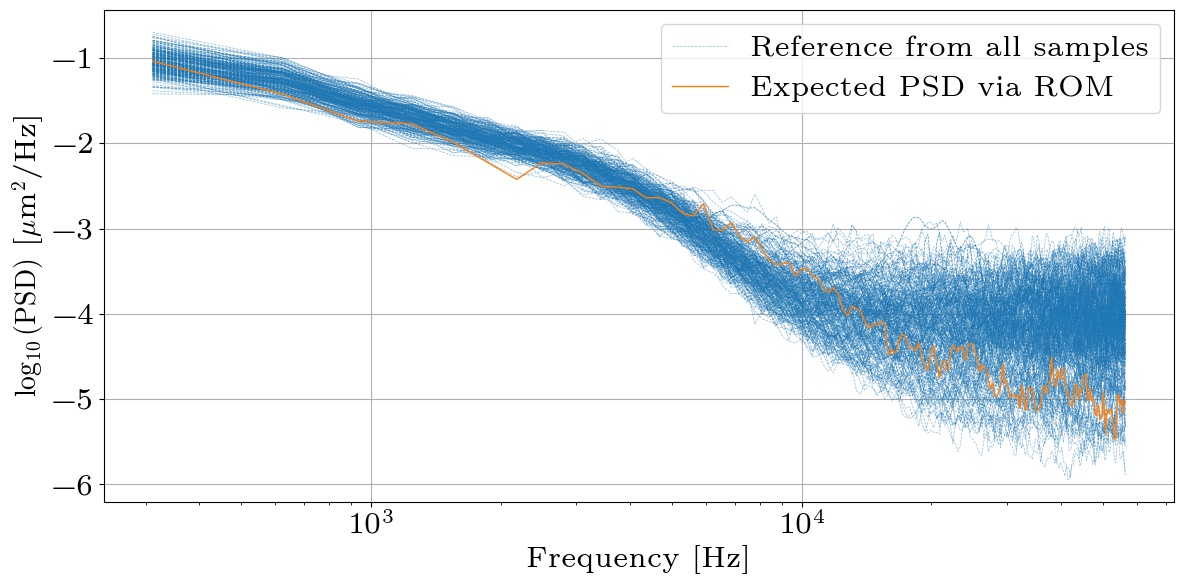

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 6))
# for i, psd_each in enumerate(psd_true_all):
#     ax.plot(f_FOM, psd_each, ls = '--', color='C0', lw=0.5, alpha=0.5, label='Reference from all samples' if i == 0 else None)

# ax.plot(f_ROM, psd_ROM + psd_diff, lw=1, alpha=1, ls="-", color='C1', label=f'Expected PSD via ROM')
# ax.set_xscale('log')
# ax.set_xlabel("Frequency [Hz]", fontsize=20)
# ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/Hz]", fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=20)
# ax.grid(True)
# plt.legend(fontsize=20)
# plt.tight_layout()
# plt.show()

In [264]:
# ── r sweep ──────────────────────────────────────────────────────────────────
r_candidates = np.arange(5, 21)          # 5, 6, ..., 25
r_results    = {}                         # keyed by r

for r in r_candidates:
    Vr_temp      = V[:, :r]
    Q_train_temp = Vr_temp.T @ Qstate_all.reshape(Vr_temp.shape[0], L * s)
    Q_train_temp = Q_train_temp.reshape(r, L, s)

    E_train = Q_train_temp.mean(axis=1)
    C_train = np.stack([np.cov(Q_train_temp[:, :, k])
                        for k in range(s)], axis=2)

    results = stoOpinf.run_grid_search(
        E_train, C_train, Q_train_temp, u_train, h_test,
        N_reg, B_reg, A_reg, Vr_temp,
        isbilinear, isBu, H_reg_opt, sigma,
        n_outer, B_loop, get_lambda,
        L, s, seed_test
    )

    E_error = results['E_error']   # shape (n_outer, n_inner)
    C_error = results['C_error']

    combined          = E_error + C_error
    best_flat         = np.nanargmin(combined)
    best_ii, best_jj  = np.unravel_index(best_flat, combined.shape)

    r_results[r] = {
        'E_error'  : E_error[best_ii, best_jj],
        'C_error'  : C_error[best_ii, best_jj],
        'combined' : combined[best_ii, best_jj],
        'best_ii'  : best_ii,
        'best_jj'  : best_jj,
        'results'  : results,
    }
    print(f"r={r:2d} | E={E_error[best_ii,best_jj]:.4e}  "
        f"C={C_error[best_ii,best_jj]:.4e}  "
        f"sum={combined[best_ii,best_jj]:.4e}  "
        f"(ii={best_ii}, jj={best_jj})")

# pick best r 
r_opt = min(r_results, key=lambda r: r_results[r]['combined'])
best  = r_results[r_opt]

print(f"\nr_opt = {r_opt}")
print(f"  E_error  = {best['E_error']:.4e}")
print(f"  C_error  = {best['C_error']:.4e}")
print(f"  combined = {best['combined']:.4e}")

# unpack the winning run 
Eopinfs, Copinfs = best['results']['Eopinfs'], best['results']['Copinfs']
EROM,    CROM    = best['results']['EROM'],    best['results']['CROM']
E_error, C_error = best['results']['E_error'], best['results']['C_error']
ROMs_all         = best['results']['ROMs_all']


1th N_reg = 1.00e+00

  lambda = [0. 0. 1.]

     k |    C_train |     Copinf |    C err |    E_train |     Eopinf |    E err
--------------------------------------------------------------------------------
     1 |   8.45e+05 |   8.44e+05 |    0.08% |   7.85e+02 |   7.85e+02 |    0.00%
  1441 |   8.41e+05 |   1.36e+06 |   61.74% |   8.21e+02 |   7.93e+02 |    3.49%
  2881 |   8.92e+05 |   9.62e+05 |    9.81% |   8.40e+02 |   8.27e+02 |    1.53%
  4321 |   9.30e+05 |   1.40e+06 |   50.19% |   8.81e+02 |   8.41e+02 |    4.67%
  5760 |   9.31e+05 |   1.29e+06 |   38.92% |   8.80e+02 |   8.71e+02 |    1.13%
--------------------------------------------------------------------------------
   Avg |            |            |   41.60% |            |            |    3.07%

  Elapsed: 0.76s

2th N_reg = 1.29e+01

  lambda = [ 0.          0.         12.91549665]

     k |    C_train |     Copinf |    C err |    E_train |     Eopinf |    E err
-----------------------------------------------------

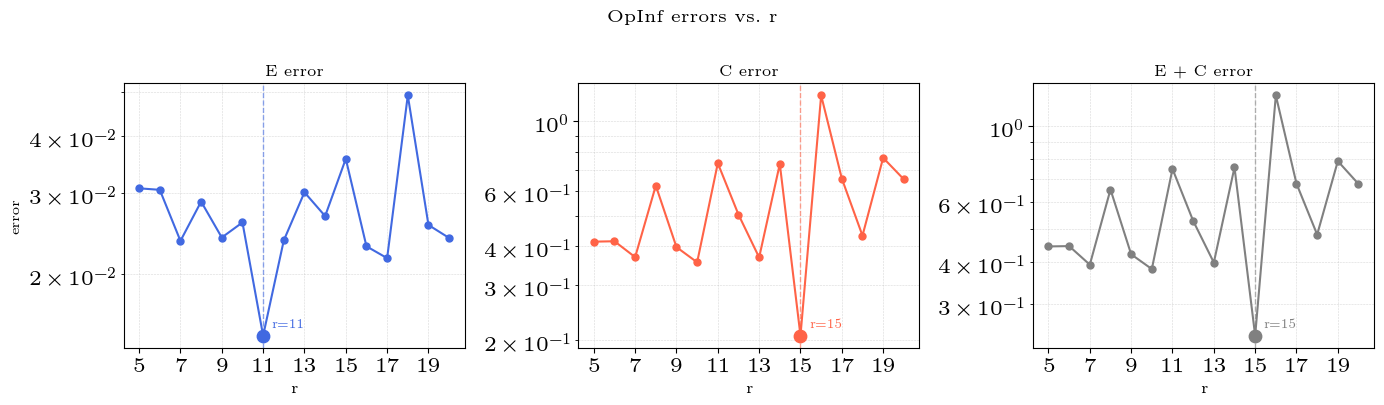

In [265]:
r_candidates = sorted(r_results.keys())
E_errs = [r_results[r]['E_error'] for r in r_candidates]
C_errs = [r_results[r]['C_error'] for r in r_candidates]
combined = [r_results[r]['combined'] for r in r_candidates]

r_opt_E   = r_candidates[np.argmin(E_errs)]
r_opt_C   = r_candidates[np.argmin(C_errs)]
r_opt_sum = r_candidates[np.argmin(combined)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, vals, label, color, r_best in zip(
    axes,
    [E_errs, C_errs, combined],
    ['E error', 'C error', 'E + C error'],
    ['royalblue', 'tomato', 'gray'],
    [r_opt_E, r_opt_C, r_opt_sum]
):
    ax.plot(r_candidates, vals, '-o', color=color, markersize=5, linewidth=1.5)
    ax.axvline(r_best, color=color, linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([r_best], [vals[r_candidates.index(r_best)]],
            color=color, s=80, zorder=5)
    ax.annotate(f'r={r_best}',
                xy=(r_best, vals[r_candidates.index(r_best)]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=9, color=color)
    ax.set_yscale('log')
    ax.set_xlabel('r', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(r_candidates[::2])
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)

axes[0].set_ylabel('error', fontsize=10)
fig.suptitle('OpInf errors vs. r', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [123]:
filename = stoOpinf.save_result(E_error, EROM, EFOM, power, r_opt, sigma, H_reg_opt, isBu)

Saved to: /disk/hyk049/WT_RomFit/0p30/0p30vpp_r=10_AN_sigma2.0_Hreg1000000.mat
Optimal indices: i_min=2, j_min=0 | E_error=0.0380


In [ ]:
# Grid search
xr0_exp = Q_train_temp[:, :, 0]   # r x L, actual experimental ICs

for ii in range(n_outer):
    import time
    t0 = time.time()
    print(f"{ii+1}th N_reg = {N_reg[ii]:.2e}")

    for jj in B_loop:
        lam = get_lambda(ii, jj)

        # Drift OpInf
        Ehatr, Ahatr, Bhatr, Nhatr = stoOpinf.infer_drift_u(
            E_train, u_train, h_test, isbilinear, isBu, lam)

        # Diffusion OpInf
        Mhatr, Khatr = stoOpinf.infer_diffusion_u(
            C_train, u_train, h_test, Ahatr, Nhatr, H_reg_opt)

        # Save operators
        ROMs_all[ii][jj] = dict(Ehat=Ehatr, Ahat=Ahatr, Bhat=Bhatr,
                                Nhat=Nhatr, Mhat=Mhatr, Khat=Khatr,
                                lam=lam, N_reg=N_reg[ii], H_reg=H_reg_opt)

        # rng = np.random.default_rng(seed_test)   # modern API
        np.random.seed(seed_test)   # legacy API
        
        # ROM step function
        def fhatr(x0, u, L_batch, k, noise_k,
                _E=Ehatr, _A=Ahatr, _B=Bhatr, _N=Nhatr, _M=Mhatr):
            lhs = _E - h_test*_A - h_test*_N*u
            noise = np.sqrt(h_test) * _M * sigma @ noise_k
            hBu = h_test*_B*u
            rhs = x0 + hBu + noise
            return np.linalg.solve(lhs, rhs)

        # Simulate ROM
        Eopinf, Copinf = stoOpinf.compute_model_u(fhatr, xr0_exp, u_train, L, L, Mhatr.shape[1])

        # Exp/Cov error over time
        # Header
        print(f"\n{'k':>6} | {'C_train':>10} | {'Copinf':>10} | {'C err':>8} | {'E_train':>10} | {'Eopinf':>10} | {'E err':>8}")
        print("-" * 80)

        for k in [0, s//4, s//2, 3*s//4, s-1]:
            E_err = la.norm(E_train[:,k] - Eopinf[:,k]) / la.norm(E_train[:,k])
            C_err = la.norm(C_train[:,:,k] - Copinf[:,:,k], 'fro') / la.norm(C_train[:,:,k], 'fro')
            print(f"{k+1:>6d} | "
                f"{la.norm(C_train[:,:,k],'fro'):>10.2e} | "
                f"{la.norm(Copinf[:,:,k],'fro'):>10.2e} | "
                f"{C_err:>8.2%} | "
                f"{la.norm(E_train[:,k]):>10.2e} | "
                f"{la.norm(Eopinf[:,k]):>10.2e} | "
                f"{E_err:>8.2%}")

        print("-" * 80)
        print(f"{'Avg':>6} | {'':>10} | {'':>10} | "
            f"{la.norm(C_train - Copinf) / la.norm(C_train):>8.2%} | "
            f"{'':>10} | {'':>10} | "
            f"{la.norm(E_train - Eopinf) / la.norm(E_train):>8.2%}")

        # Store
        Eopinfs[ii][jj] = Eopinf
        Copinfs[ii][jj] = Copinf
        EROM[ii][jj]    = Vr_temp @ Eopinf
        CROM[ii][jj]    = Copinf

        E_error[ii,jj]  = la.norm(E_train - Eopinf, 'fro') / la.norm(E_train, 'fro')
        C_error[ii,jj]  = stoOpinf.page_norm(C_train - Copinf) / stoOpinf.page_norm(C_train)

    print(f"  Elapsed: {time.time()-t0:.2f}s")